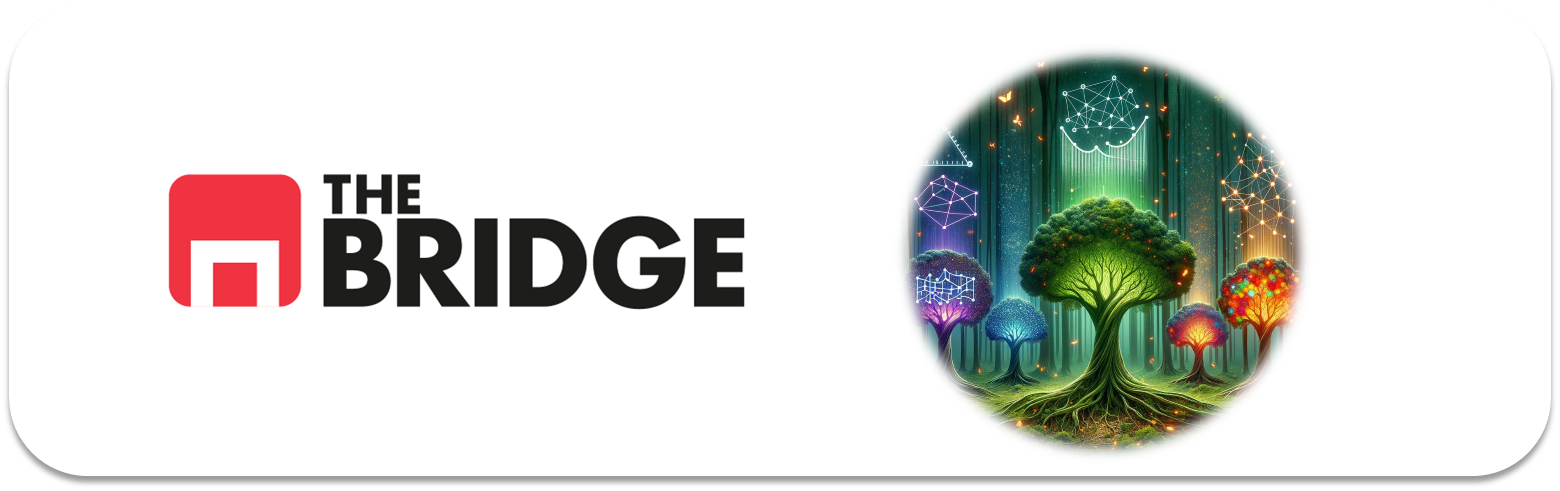

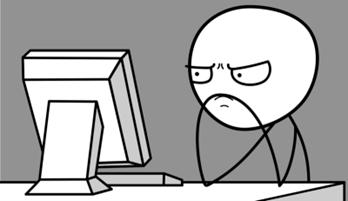

Para ejercitarte y afianzar lo aprendido sobre **Clasificacion con Árboles de decisión**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt


### Ejercicio 1

Genera un conjunto de datos de lunas usando 

```python
make_moons(n_samples=10000, noise=0.4)
```

La función make_moons se encuentra en el módulo `datasets` de `sklearn`. Juega con ella para ver qué tipo de datos genera, y  crea un X_moons y un y_moons. Visualiza las moons con un scatter plot de las dos features de X_moons. (ojo X_moons es un array de numpy de dos dimesiones para acceder a la primera X_moons[:,0] y para la segunda...)

In [2]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=10000, noise=0.4)

<Axes: >

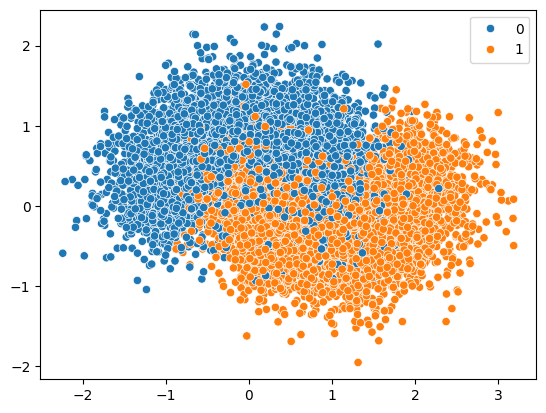

In [3]:
sns.scatterplot(x = X_moons[:,0], y = X_moons[:,1], hue = y_moons)

### Ejercicio 2

El objetivo de los modelos que vamos a ir construyendo es aprender a clasificar correctamente en cada "luna" (moon) a un punto dadas sus coordenadas. Para ello crea un par de juegos X,y para train y test al 20% de test a partir de los puntos generados en el ejercicio anterior.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

Train: 8000 muestras
Test: 2000 muestras


### Ejercicio 3

Instancia un árbol de decisión de `sklearn` sin añadir hiperparámetros.

In [5]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier()

### Ejercicio 4

Entrena el árbol y evalúalo contra test, usa para ello el classification_report de `sklearn`

In [6]:
from sklearn.metrics import classification_report

tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.79      0.78       964
           1       0.80      0.76      0.78      1036

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



### Ejercicio 5

Instancia un nuevo árbol con los hiperparámetros (argumentos del constructor), `max_depth` a 5 y `max_leaf_nodes` a 15. Busca en la documentación de `sklearn` el significado de ambos hiperparámetros.

In [7]:
tree_clf2 = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15)

### Ejercicio 6

Entrénalo, evaluálo contra test y muestra el resultado a través del classification_report.

In [8]:
tree_clf2.fit(X_train, y_train)
y_pred2 = tree_clf2.predict(X_test)

print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       964
           1       0.85      0.87      0.86      1036

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



Comenta el resultado

*La mejor es sensible, debido a que el ajuste de hiperparámetros ha sido bastante bueno. En general los modelos basados en árboles necesitan un ajuste más fino que las regresiones (lineal, que apenas hay que hacer nada, y logística)*

### Ejercicio 7

Genera 1000 subconjuntos a partir del X_train, cada uno con 100 instancias seleccionadas aleatoriamente. Pista: Revisa la clase `ShuffleSplit` de `sklearn` para ayudarte con esto

In [9]:
from sklearn.model_selection import ShuffleSplit

rs = ShuffleSplit(n_splits=1000, test_size=len(X_train) - 100, random_state=42)

### Ejercicio 8

Entrena un árbol de decisión por cada subconjunto anterior (ve acumulándolos en una lista, llámala "bosque" o "forest"). Emplea como hiperparámetros los del ejercicio 5.

In [10]:
forest = []

for train_index, _ in rs.split(X_train):
    X_subset = X_train[train_index]
    y_subset = y_train[train_index]

    tree = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15)
    tree.fit(X_subset, y_subset)

    forest.append(tree)

print("Arboles entrenados:", len(forest))





Arboles entrenados: 1000


### Ejercicio 9

Evalua cada árbol del bosque contra X_test original en la métrica de `accuracy` y muestra la media de todas las medidas. Emplea para ello `accuracy_score` de `sklearn`. Comenta el resultado.

In [11]:
from sklearn.metrics import accuracy_score

accuracies = []

for tree in forest:
    acc = accuracy_score(y_test, tree.predict(X_test))
    accuracies.append(acc)

print(f"Accuracy media: {np.mean(accuracies):.4f}")


Accuracy media: 0.7975


*Como era un poco de esperar un árbol entrenado con menor cantidad de datos no está a la altura de otro entrenado sobre el mismo dataset pero con mayor cantidad de información (81% vs 86%). Es lo que se denomina weak_learner*

### Ejercicio 10

Vamos a hacer un consejo de árboles... Es decir ahora vuelve a predecir las instancias de X_test para cada árbol pero guarda las predicciones en una lista. Es decir crea una lista con los 1000 conjuntos de predicciones (uno por cada árbol)

In [12]:
predicciones = []

for tree in forest:
    y_pred = tree.predict(X_test)
    predicciones.append(y_pred)

print(f"Número de conjuntos de predicciones: {len(predicciones)}")

Número de conjuntos de predicciones: 1000


### Ejercicio 11

Ahora vamos a construir la predicción final del consejo de árboles mediante un mecanismo de "hard-voting" es decir para cada predicción escoge la clase más votada. Puedes hacerlo recorriendo cada lista de predicciones y contando cual clase tiene más votos y apuntándolo o usando `mode` (la moda) de `scipy`

In [13]:
# Ejemplo de votación para la primera instancia de X_test
Y_pred_consejo = []
votos_0 = 0
votos_1 = 0
for i in range(len(forest)):
    if predicciones[i][0] == 0:
        votos_0 += 1
    else:
        votos_1 += 1

if votos_0 > votos_1:
    Y_pred_consejo.append(0)
else:
    Y_pred_consejo.append(1)

print(f"Predicciones finales {len(Y_pred_consejo)}")

Predicciones finales 1


In [14]:

from scipy.stats import mode
import numpy as np

predictions_array = np.array(predicciones)  # shape (1000, 2000)

y_pred_consejo, votos = mode(predictions_array, axis=0)

print(f"Shape predicciones finales: {y_pred_consejo.shape}")
print(f"Primeras 10 predicciones:   {y_pred_consejo[:10]}")
print(f"Votos de la clase ganadora (primeras 10): {votos[:10]}")

Shape predicciones finales: (2000,)
Primeras 10 predicciones:   [0 1 1 0 1 1 0 0 0 1]
Votos de la clase ganadora (primeras 10): [554 902 952 937 928 939 947 959 965 893]


### Ejercicio 12

Evalua las predicciones del consejo contra y_test y comenta el resultado. Utiliza `accuracy_score`

In [16]:
accuracy_consejo = accuracy_score(y_test, y_pred_consejo)

print("Accuracy del consejo:", round(accuracy_consejo, 2))


Accuracy del consejo: 0.86
